# Friends of Friends

Perhaps the simplest way to find clusters:
What points are close enough to other points to be considered friends?
And which friend groups have common memebers?

Here we will work through an example (or three) of how to find these groups.

These methods are not necessarily the fastest or most efficient ways to build FoF groups but they should give you a good feeling for how it works. And there is nothing stopping you optimising the methods we will explore, or writing something even faster. They also use some of the most basic Python libraries, so are simple to impliment by design.

Let's include our libraries

In [1]:
import numpy as np              #To make some operations easier
import matplotlib.pyplot as plt #To see what we are doing

## Some Data
To run FoF, we need some data. To get used to the method, we will create a toy set of data. We will do this by randomly sampling a small amount of data from three Gaussian Distributions.

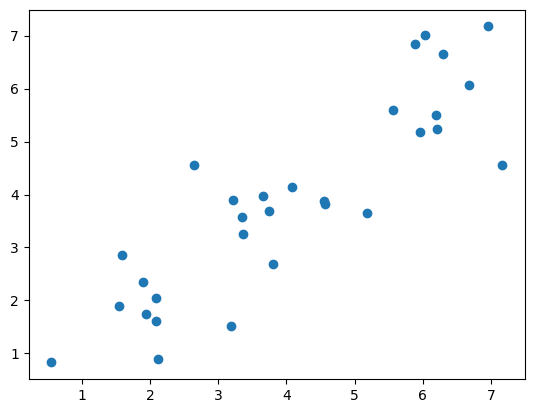

In [2]:
#While we play around, we want our results to be repeatable. So let's set a seed
np.random.seed(256)

#Draw 10 random points from a 2D Gaussian with
point_1 = np.random.multivariate_normal([2,2], [[0.75,0],[0,0.5]], 10) #mean=[2,2] and std=[0.75,0.5]
point_2 = np.random.multivariate_normal([6,6], [[0.5,0],[0,0.75]], 10) #mean=[6,6] and std=[0.5,0.75]
point_3 = np.random.multivariate_normal([4,4], [[0.5,0],[0,0.5]], 10)  #mean=[4,4] and std=[0.5,0.5]

#Join our points together into one list
points = np.vstack((point_1, point_2, point_3))
idx = np.arange(0, len(points))

#As the order of points shouldn't matter, let's shuffle them
np.random.shuffle(idx)
points = points[idx]

#Plot the points to see where we are starting from
plt.scatter(points[:,0], points[:,1])
plt.show()

If you made some dimensionally reduced data this morning, you can load that insead if you prefer.

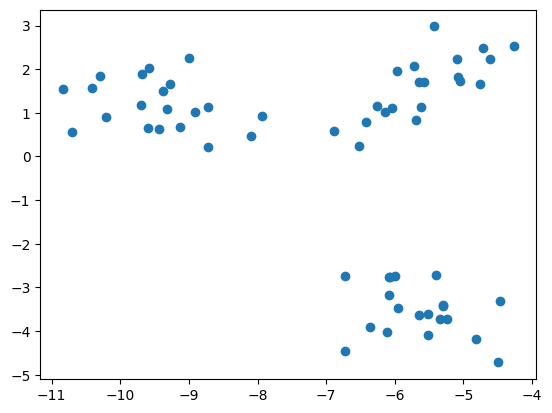

In [3]:
#Load our data from this morning
data_source = 'TSVD' #'TSVD', 'PCA', or "SOM
points = np.load(data_source+'_Z.npy')

#####################
#If we are using the SOM data, we have many points in one position
#To make things easier, we will only use unique positions
#if data_source == 'SOM':
#    points_tupl = [tuple(elem) for elem in points]
#    points = []
#    for pt in points_tupl:
#        if pt not in points:
#            points.append(pt)
#    points = np.array(points)
#####################

#As the order of points shouldn't matter, let's shuffle them
idx = np.arange(0, len(points))
np.random.shuffle(idx)
points = points[idx]

#Plot the points to see where we are starting from
plt.scatter(points[:,0], points[:,1])
plt.show()

## Find the friends

Probably the most obvious place to start, it to find out which points are friends to which other points. We need to start this by deciding how close a point needs to be to be considered a friend: we need to chose the linking length.

In [4]:
linking_length = np.sqrt(2)+0.01

Now we can use that length to find each point's friend group. For point x_i, which other points are closer than the linking length.

How you want to achieve this is up to you.

In [5]:
def find_friend_groups(points, linking_length):

    #####################
    friend_groups = {}
    for i in range(0, len(points)):
        dists = np.sqrt(np.square(points[i,0]-points[:,0])+np.square(points[i,1]-points[:,1]))
        friends = np.where(dists < linking_length)[0]
        friend_groups[i] = friends.tolist()
    ######################
    
    return friend_groups

friend_groups = find_friend_groups(points, linking_length)

To find the clusters, we need to merge the friend groups based on shared friends. Each point should only appear in one cluster.

In [6]:
def merge_friend_groups(friend_groups):

    #####################
    keys = list(friend_groups.keys())
    for i in keys:
        if i not in friend_groups.keys():
            continue
        friends = friend_groups[i]
        for f in friends:
            if f == i:
                continue
            if f in friend_groups.keys():
                friend_groups[i] += friend_groups[f]
                del friend_groups[f]
        friend_groups[i] = np.unique(friend_groups[i]).tolist()

    clusters = []
    for i in friend_groups.keys():
        clusters.append(friend_groups[i])
    #####################
    
    return clusters

clusters = merge_friend_groups(friend_groups)

Now is a good time to plot our clusters to see what we have found. I would write the code to do this for you but I have no idea how your data is structured. I would suggest using different colours for each cluster so you can visually see the clusters you found.

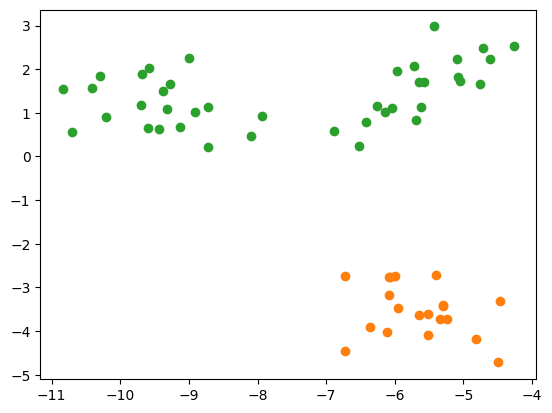

In [7]:
def plot_clusters(points, clusters):
    
    #####################
    colours = ['tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
    
    g = 0
    for group in clusters:
        if len(group) == 1:
            c = 'tab:blue'
        else:
            c = colours[g]
            g += 1
            if g == len(colours):
                g = 0
        plt.scatter(points[group,0], points[group,1], c=c)
    plt.show()
    #####################

    return

plot_clusters(points, clusters)

## A better way?

That is a conceptually simple way to run FoF: find the friend group for each point, and merge the points.
But what if we start at one random point and build it's entire cluster. Then move on to the next point not in a cluster and build that point's cluster. And so on. This is starting to sound a bit like traversing a (mathematical) graph...

...for which there are many way to approach this problem people have come up with. We will look at Breadth First Search and Depth First Search. These are not the only ways to do it but are two methods I personally find fun to code.

### Breadth First Search (BFS)

Also sometimes called Flood Fill. This search algorithm starts at a point, finds all the places that can be reached from that position, and adds those points into a list (normally called a queue). Then, remove the first point in the queue from the queue, find all the places that can be reached _that have not already been visited_, and add those positions to the end of the queue. Repeat this until the queue is empty.

As I suspect many of you will not have heard of BFS before, I will try to help guide you through the process.

In [8]:
def BFS(start, points, linking_length):
    # I reccomend making points a list of tuples 
    # as Python can search for a tuple in a list 
    # more easily than for a list in a list

    #####################
    points_tupl = [tuple(elem) for elem in points]
    cluster = [points_tupl[start]]
    #####################

    # if start is an index,
    queue = [points[start]]
    # if not, add your starting position into the queue

    # Keep running until queue is empty
    while len(queue):
        # We want to remove the first element from the list
        # list.pop(x) removes the xth element of the list, 
        # and returns that element
        x_i = queue.pop(0)

        # Find the friends of x_i

        #####################
        dists = np.sqrt(np.square(x_i[0]-points[:,0])+np.square(x_i[1]-points[:,1]))
        friends = np.where(dists < linking_length)[0]
        #####################

        # If those friends have not been visited, 
        # add them to the cluster
        # and add them to the queue

        #####################
        for f in friends:
            if points_tupl[f] not in cluster:
                cluster.append(points_tupl[f])
                queue.append(points[f])
        #####################

    # If you need to, edit the format of your group to match how your groups were made before
    # This will make plotting them easier
    #####################
    group_idx = []
    for point in cluster:
        for i, tp in enumerate(points_tupl):
            if point == tp:
                group_idx.append(i)

    return group_idx
    #####################
    
    return cluster

You now have a BFS function that will find the cluster of a single point. You will need to find the clusters for all the points.
Remember that each point can only exist in one cluster, so you do not need to run BFS on every point.

In [9]:
def FoF_BFS(points, linking_length):

    #####################
    clusters = []
    idx = np.arange(0, len(points)).tolist()
    while len(idx):
        i = idx[0]
        cluster = BFS(i, points, linking_length)
        clusters.append(cluster)
        
        for g in cluster:
            idx.remove(g)
    #####################

    return clusters

cluster_BFS = FoF_BFS(points, linking_length)

If all has gone well, the next plot should show the same clusters as the previous plot.

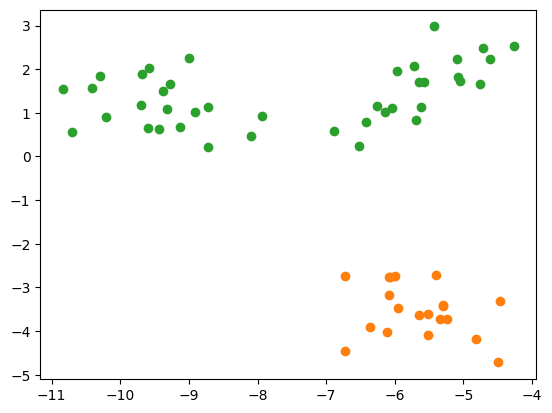

In [10]:
plot_clusters(points, cluster_BFS)

### Depth First Search (DFS)

Instead of checking what points each friend can reach in turn, we can instead travel from our start point outwards until we can go no further and back track to the last split point. To better understand, imagine a tree. BFS will find each leaf closest to the tree trunk first, then move outwards to the second closest leave, and so on. DFS, on the other hand, will travel along a branch finding each leaf on the left of the branch until it reaches the final leaf. DFS then goes back to the last split in the branch and moves along this secondary branch, and so on. BFS will map the leaves closest to the trunk first, while DFS will map all the leaves on one branch first. If that doesn't make sense, ask me and I will draw pictures to help explain.

To actually run DFS, we will need to use recursion: we will call a function from within itself. (There are other ways to do this but I think recursion is the simplest.) As I don't expect many of you to have heard or used recursion or DFS, I will try to help you through it.

In [11]:
def DFS(start, points, linking_length, cluster):
    # Here, cluster needs to be updated during recursion
    # The easiest and safest way is by passing cluster to DFS
    # and returning cluster from DFS

    # if start is an index ,
    x_i = points[start]
    # if not, deal with start as necessary to get the starting point as x_i

    # Find the friends of x_i

    #####################
    dists = np.sqrt(np.square(x_i[0]-points[:,0])+np.square(x_i[1]-points[:,1]))
    friends = np.where(dists < linking_length)[0]
    #####################

    # For the friends that are not already in the group
    # Call DFS with the starting point being a friend
    # Remembering to have updated your cluster

    #####################
    for friend in friends:
        if friend not in cluster:
            cluster.append(int(friend))
    #####################
            cluster = DFS(friend, points, linking_length, cluster)

    return cluster

You now have a DFS function that will find the cluster of a single point. You will need to find the clusters for all the points.

In [12]:
def FoF_DFS(points, linking_length):

    #####################
    clusters = []
    idx = np.arange(0, len(points)).tolist()
    while len(idx):
        i = idx[0]
        cluster = DFS(i, points, linking_length, [i])
        clusters.append(cluster)
        for g in cluster:
            idx.remove(g)
    #####################

    return clusters

cluster_DFS = FoF_DFS(points, linking_length)

If all has gone well, the next plot should show the same clusters as the first set you found and DFS.

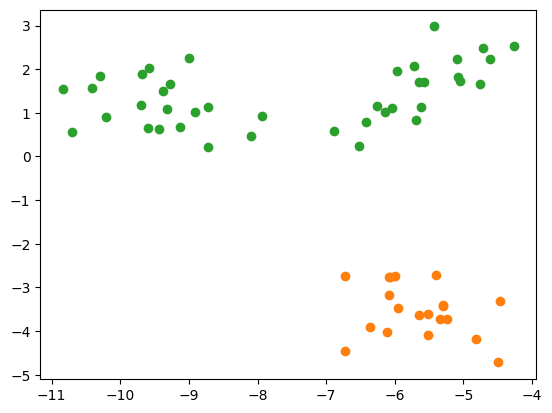

In [13]:
plot_clusters(points, cluster_DFS)

## Real Data

We can also play with our dimensionality reduction of our real data we made earlier. Let's load that and see what we find.

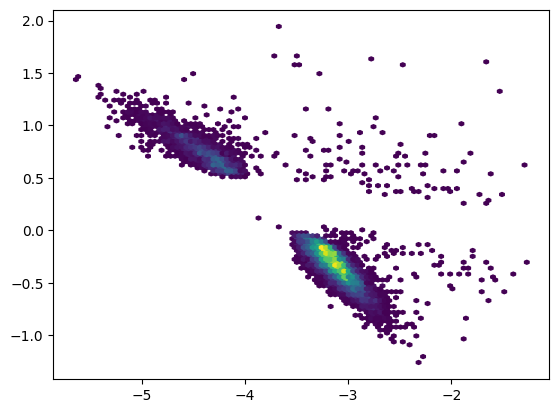

In [14]:
#Load our data from this morning
data_source = 'TSVD' #'TSVD', 'PCA', or "SOM
Z_data = np.load(data_source+'_data.npy')

plt.hexbin(Z_data[:,0], Z_data[:,1], mincnt=1)
plt.show()

Now run one (or all) of the FoF alogrithms in it and see what we find. Play around with the linking_length

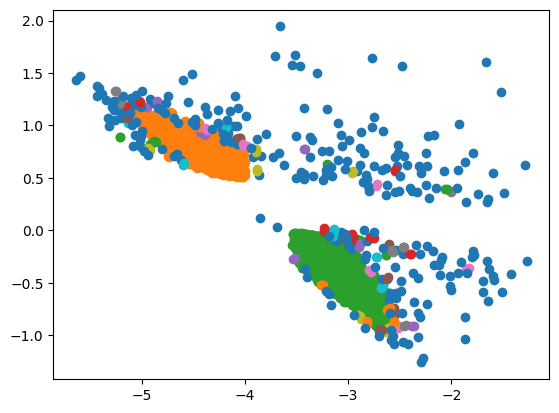

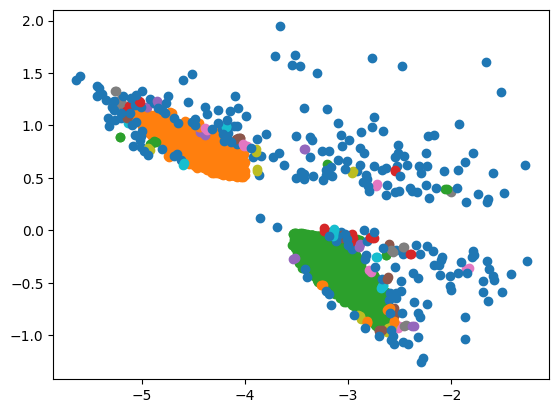

In [18]:
linking_length = 0.03

friend_groups = find_friend_groups(Z_data, linking_length)
clusters = merge_friend_groups(friend_groups)
plot_clusters(Z_data, clusters)

#####################
clusters_BFS = FoF_BFS(Z_data, linking_length)
plot_clusters(Z_data, clusters_BFS)

#clusters_DFS = FoF_DFS(Z_data, linking_length)
#plot_clusters(Z_data, clusters_DFS)
#####################

Now we have our clusters, you can go back to our data to better understand what you found.